# Installation of Required Libraries

This cell ensures that all necessary libraries for the notebook's execution are installed. It is placed at the beginning of the notebook to guarantee that dependencies are met before any other code is run.

In [1]:
!pip install numpy pandas matplotlib scikit-learn umap-learn


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\con_l\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



# QML Feature Engineering Notebook (2 qubits)

Este notebook te ayuda a decidir qué representación de **2 features** conviene usar antes de alimentar un VQC de 2 qubits.

## Qué valida
- Comparación de los **6 pares posibles** de features originales de Iris.
- Comparación contra **PCA(2)**.
- Comparación contra **LDA + 1 feature original**.
- Separación correcta de **train/test antes de ajustar transformaciones** para evitar fuga de información.
- Escalado final al rango **[0, pi]** para codificación angular.
- Gráficos listos para el informe.

## Recomendación de uso
1. Ejecuta todo el notebook con la configuración por defecto.
2. Mira primero los gráficos y la tabla de ranking de representaciones.
3. Elige la representación final de 2 dimensiones para el dataset del modelo cuántico.
4. Exporta el CSV final ya escalado a [0, pi].


In [2]:

import itertools
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

OUTPUT_DIR = Path('output_qml_feature_analysis')
OUTPUT_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42



## 1. Configuración del problema

Puedes cambiar las clases aquí.

- `(0, 1)` = Setosa vs Versicolor
- `(1, 2)` = Versicolor vs Virginica
- `(0, 2)` = Setosa vs Virginica

**Sugerencia metodológica:** usa `(0, 1)` como caso piloto y luego repite con `(1, 2)` para tener un problema menos trivial.


In [3]:

CLASS_PAIR = (1, 2)
TEST_SIZE = 0.2
ANGLE_RANGE = (0, np.pi)

iris = load_iris(as_frame=True)
df_full = iris.frame.copy()
feature_names = iris.feature_names
class_names = iris.target_names

mask = df_full['target'].isin(CLASS_PAIR)
df = df_full.loc[mask, list(feature_names) + ['target']].copy()

# Map target to 0 and 1 to avoid issues with downstream metrics and classifiers
df['target'] = df['target'].map({CLASS_PAIR[0]: 0, CLASS_PAIR[1]: 1})

# Map names to 0 and 1
name_map = {0: class_names[CLASS_PAIR[0]], 1: class_names[CLASS_PAIR[1]]}
df['target_name'] = df['target'].map(name_map)

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
50,7.0,3.2,4.7,1.4,0,versicolor
51,6.4,3.2,4.5,1.5,0,versicolor
52,6.9,3.1,4.9,1.5,0,versicolor
53,5.5,2.3,4.0,1.3,0,versicolor
54,6.5,2.8,4.6,1.5,0,versicolor


In [4]:

X = df[list(feature_names)].copy()
y = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)
print('Classes    :', {k: v for k, v in name_map.items()})


Train shape: (80, 4)
Test shape : (20, 4)
Classes    : {0: np.str_('versicolor'), 1: np.str_('virginica')}



## 2. Exploración visual de los 6 pares originales

Esto sirve para la **selección manual de 2 features**: elegir directamente dos variables originales del dataset sin aplicar reducción de dimensionalidad.


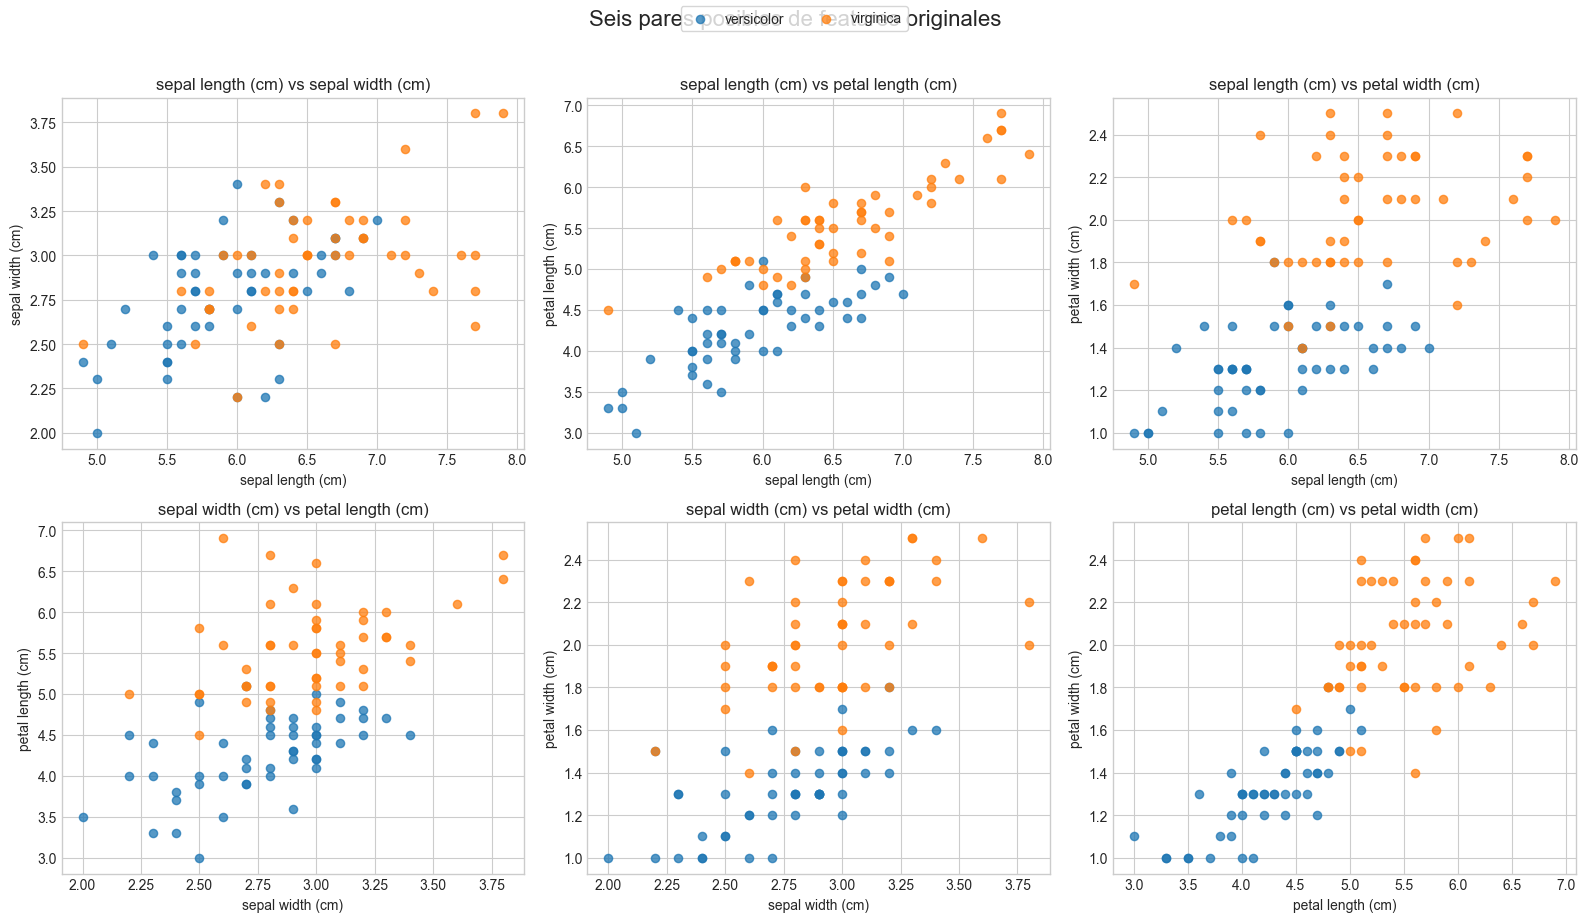

In [5]:

pairs = list(itertools.combinations(feature_names, 2))
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
colors = ['#1f77b4', '#ff7f0e']

for ax, (f1, f2) in zip(axes, pairs):
    for label, color in zip(sorted(y.unique()), colors):
        mask = y == label
        ax.scatter(X.loc[mask, f1], X.loc[mask, f2], s=35, alpha=0.75, label=name_map[label], color=color)
    ax.set_title(f'{f1} vs {f2}')
    ax.set_xlabel(f1)
    ax.set_ylabel(f2)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=True)
fig.suptitle('Seis pares posibles de features originales', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_raw_feature_pairs.png', dpi=180, bbox_inches='tight')
plt.show()



## 3. Ranking de todos los pares originales

Se usa una baseline clásica simple (regresión logística con estandarización) solo para estimar qué tan separable es cada par.
No reemplaza al VQC; solo te ayuda a decidir el dataset 2D que vale la pena probar primero.


In [6]:

def fisher_ratio_2d(X2, y):
    classes = np.unique(y)
    means = []
    covs = []
    counts = []
    for c in classes:
        Xc = X2[y == c]
        means.append(Xc.mean(axis=0))
        covs.append(np.cov(Xc.T))
        counts.append(len(Xc))
    mean_diff = np.linalg.norm(means[0] - means[1]) ** 2
    sw = covs[0] + covs[1]
    denom = np.trace(sw)
    return float(mean_diff / denom) if denom > 0 else np.nan

rows = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for f1, f2 in pairs:
    cols = [f1, f2]
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ])
    X_pair = X_train[cols]
    scores = cross_val_score(pipe, X_pair, y_train, cv=cv, scoring='accuracy')
    fr = fisher_ratio_2d(X_pair.values, y_train.values)
    rows.append({
        'representation': f'{f1} + {f2}',
        'type': 'raw_pair',
        'cv_acc_mean': scores.mean(),
        'cv_acc_std': scores.std(),
        'fisher_ratio': fr,
        'features': cols
    })

pair_results = pd.DataFrame(rows).sort_values(['cv_acc_mean', 'fisher_ratio'], ascending=False).reset_index(drop=True)
pair_results


,representation,type,cv_acc_mean,cv_acc_std,fisher_ratio,features
0,petal length (cm) + petal width (cm),raw_pair,0.9750,0.030619,3.764304,"[petal length (cm), petal width (cm)]"
1,sepal width (cm) + petal width (cm),raw_pair,0.9625,0.030619,2.333051,"[sepal width (cm), petal width (cm)]"
2,sepal length (cm) + petal width (cm),raw_pair,0.9625,0.030619,1.446860,"[sepal length (cm), petal width (cm)]"
3,sepal length (cm) + petal length (cm),raw_pair,0.9375,0.055902,1.913153,"[sepal length (cm), petal length (cm)]"
4,sepal width (cm) + petal length (cm),raw_pair,0.9250,0.046771,2.578294,"[sepal width (cm), petal length (cm)]"
5,sepal length (cm) + sepal width (cm),raw_pair,0.6875,0.142522,0.649089,"[sepal length (cm), sepal width (cm)]"


In [7]:

best_pair = pair_results.iloc[0]['features']
print('Mejor par original:', best_pair)

pair_results.to_csv(OUTPUT_DIR / '02_raw_pair_ranking.csv', index=False)
pair_results.head(6)


Mejor par original: ['petal length (cm)', 'petal width (cm)']


,representation,type,cv_acc_mean,cv_acc_std,fisher_ratio,features
0,petal length (cm) + petal width (cm),raw_pair,0.9750,0.030619,3.764304,"[petal length (cm), petal width (cm)]"
1,sepal width (cm) + petal width (cm),raw_pair,0.9625,0.030619,2.333051,"[sepal width (cm), petal width (cm)]"
2,sepal length (cm) + petal width (cm),raw_pair,0.9625,0.030619,1.446860,"[sepal length (cm), petal width (cm)]"
3,sepal length (cm) + petal length (cm),raw_pair,0.9375,0.055902,1.913153,"[sepal length (cm), petal length (cm)]"
4,sepal width (cm) + petal length (cm),raw_pair,0.9250,0.046771,2.578294,"[sepal width (cm), petal length (cm)]"
5,sepal length (cm) + sepal width (cm),raw_pair,0.6875,0.142522,0.649089,"[sepal length (cm), sepal width (cm)]"



## 4. PCA(2) sin fuga de información

PCA se ajusta **solo con entrenamiento** y luego transforma train y test.


In [8]:

pca_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=RANDOM_STATE))
])

X_train_pca = pca_pipe.fit_transform(X_train, y_train)
X_test_pca = pca_pipe.transform(X_test)

pca_model = pca_pipe.named_steps['pca']
print('Explained variance ratio:', pca_model.explained_variance_ratio_)
print('Total explained variance:', pca_model.explained_variance_ratio_.sum())


Explained variance ratio: [0.74584388 0.13257399]
Total explained variance: 0.8784178732711688


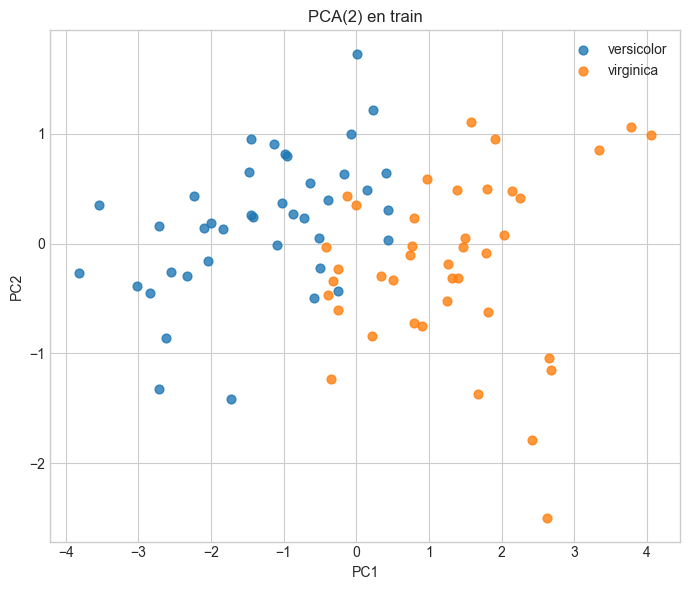

In [9]:

fig, ax = plt.subplots(figsize=(7, 6))
for label, color in zip(sorted(np.unique(y_train)), colors):
    mask = y_train == label
    ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], s=40, alpha=0.8, color=color, label=name_map[label])
ax.set_title('PCA(2) en train')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_pca_train_projection.png', dpi=180, bbox_inches='tight')
plt.show()



## 5. LDA como referencia supervisada

En binario, LDA genera una dirección discriminante principal de 1D.
Para adaptarlo a 2 qubits, aquí se construye una representación de 2D usando:

- `LDA1`
- la mejor feature original individual según ranking de accuracy


In [10]:

feature_single_rows = []
for f in feature_names:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ])
    scores = cross_val_score(pipe, X_train[[f]], y_train, cv=cv, scoring='accuracy')
    feature_single_rows.append({'feature': f, 'cv_acc_mean': scores.mean(), 'cv_acc_std': scores.std()})

single_feature_ranking = pd.DataFrame(feature_single_rows).sort_values('cv_acc_mean', ascending=False).reset_index(drop=True)
best_single_feature = single_feature_ranking.iloc[0]['feature']
single_feature_ranking


,feature,cv_acc_mean,cv_acc_std
0,petal width (cm),0.9625,0.030619
1,petal length (cm),0.9125,0.030619
2,sepal length (cm),0.7000,0.114564
3,sepal width (cm),0.6500,0.075000


In [11]:

lda_scaler = StandardScaler()
X_train_std = lda_scaler.fit_transform(X_train)
X_test_std = lda_scaler.transform(X_test)

lda = LinearDiscriminantAnalysis(n_components=1)
X_train_lda1 = lda.fit_transform(X_train_std, y_train)
X_test_lda1 = lda.transform(X_test_std)

X_train_lda2 = np.column_stack([X_train_lda1.ravel(), X_train[best_single_feature].values])
X_test_lda2 = np.column_stack([X_test_lda1.ravel(), X_test[best_single_feature].values])

print('Feature complementaria para LDA:', best_single_feature)
print('Shape LDA+raw train:', X_train_lda2.shape)


Feature complementaria para LDA: petal width (cm)
Shape LDA+raw train: (80, 2)


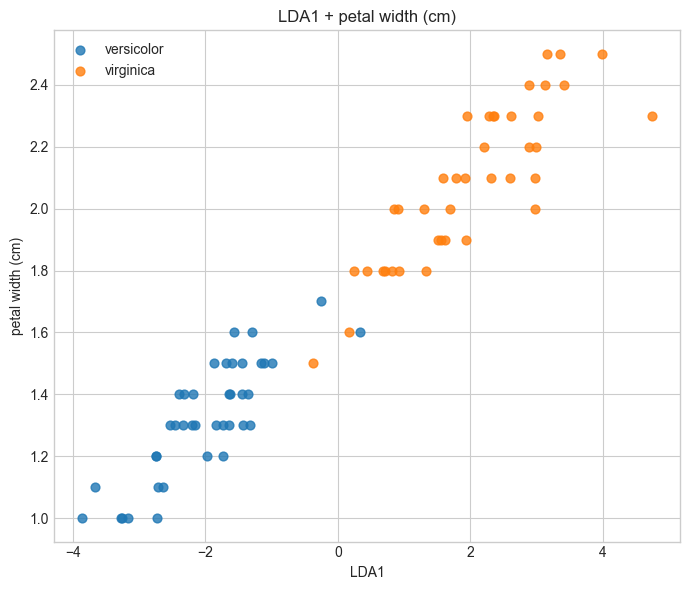

In [12]:

fig, ax = plt.subplots(figsize=(7, 6))
for label, color in zip(sorted(np.unique(y_train)), colors):
    mask = y_train == label
    ax.scatter(X_train_lda2[mask, 0], X_train_lda2[mask, 1], s=40, alpha=0.8, color=color, label=name_map[label])
ax.set_title(f'LDA1 + {best_single_feature}')
ax.set_xlabel('LDA1')
ax.set_ylabel(best_single_feature)
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_lda_plus_best_raw.png', dpi=180, bbox_inches='tight')
plt.show()



## 6. Comparación formal entre representaciones 2D candidatas

Se comparan tres candidatas:
- mejor par original,
- PCA(2),
- LDA1 + mejor feature original.


In [13]:

def eval_representation(Xtr, Xte, ytr, yte, name):
    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ])
    clf.fit(Xtr, ytr)
    pred = clf.predict(Xte)
    prob = clf.predict_proba(Xte)[:, 1]
    return {
        'representation': name,
        'test_accuracy': accuracy_score(yte, pred),
        'test_f1': f1_score(yte, pred),
        'test_auc': roc_auc_score(yte, prob)
    }

candidates = {}

Xtr_best_pair = X_train[best_pair].values
Xte_best_pair = X_test[best_pair].values
candidates['best_raw_pair'] = (Xtr_best_pair, Xte_best_pair)
candidates['pca_2d'] = (X_train_pca, X_test_pca)
candidates['lda1_plus_best_raw'] = (X_train_lda2, X_test_lda2)

comparison_rows = []
for name, (Xtr, Xte) in candidates.items():
    comparison_rows.append(eval_representation(Xtr, Xte, y_train, y_test, name))

comparison_df = pd.DataFrame(comparison_rows).sort_values(['test_accuracy', 'test_f1', 'test_auc'], ascending=False).reset_index(drop=True)
comparison_df.to_csv(OUTPUT_DIR / '05_representation_comparison.csv', index=False)
comparison_df


,representation,test_accuracy,test_f1,test_auc
0,lda1_plus_best_raw,0.90,0.900000,0.98
1,best_raw_pair,0.85,0.842105,0.97
2,pca_2d,0.80,0.800000,0.93



## 7. Visualizaciones bonitas para el informe

### 7.1 PCA, t-SNE y UMAP
- **PCA**: útil como proyección lineal reproducible.
- **t-SNE**: útil para visualización; no conviene usarlo directamente como feature de entrenamiento.
- **UMAP**: opcional; si no está instalado, el notebook lo omite sin romperse.


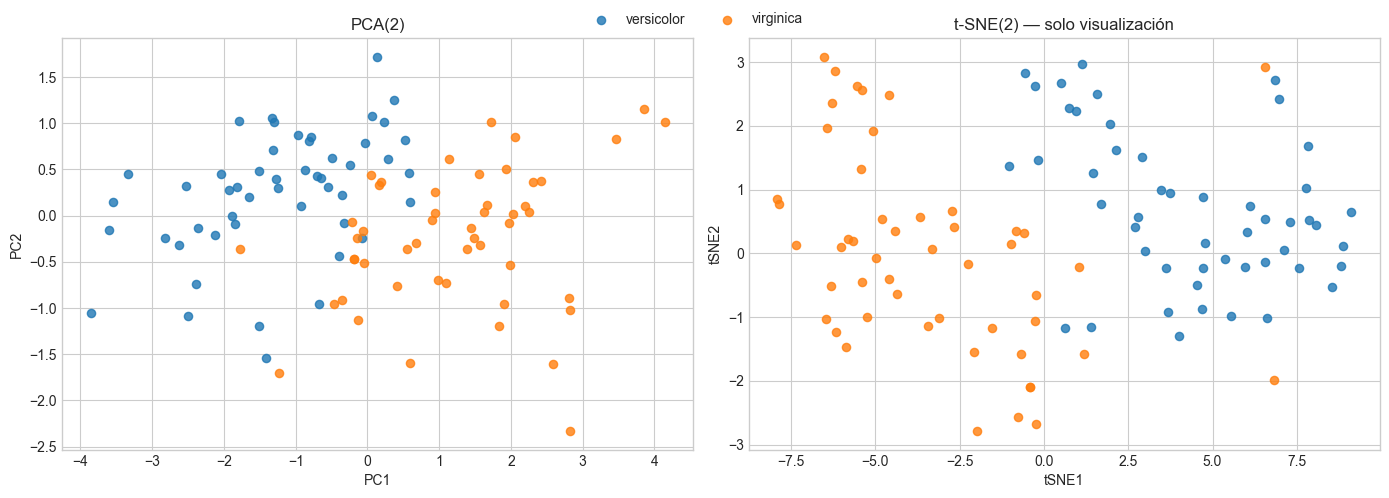

In [14]:

X_all_std = StandardScaler().fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

X_all_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_all_std)
for label, color in zip(sorted(np.unique(y)), colors):
    mask = y == label
    axes[0].scatter(X_all_pca[mask, 0], X_all_pca[mask, 1], s=35, alpha=0.8, color=color, label=name_map[label])
axes[0].set_title('PCA(2)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

X_all_tsne = TSNE(n_components=2, random_state=RANDOM_STATE, init='pca', learning_rate='auto', perplexity=min(30, len(X)//3)).fit_transform(X_all_std)
for label, color in zip(sorted(np.unique(y)), colors):
    mask = y == label
    axes[1].scatter(X_all_tsne[mask, 0], X_all_tsne[mask, 1], s=35, alpha=0.8, color=color, label=name_map[label])
axes[1].set_title('t-SNE(2) — solo visualización')
axes[1].set_xlabel('tSNE1')
axes[1].set_ylabel('tSNE2')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_pca_vs_tsne.png', dpi=180, bbox_inches='tight')
plt.show()


In [ ]:

import umap
X_all_umap = umap.UMAP(n_components=2, random_state=RANDOM_STATE).fit_transform(X_all_std)
fig, ax = plt.subplots(figsize=(7, 6))
for label, color in zip(sorted(np.unique(y)), colors):
    mask = y == label
    ax.scatter(X_all_umap[mask, 0], X_all_umap[mask, 1], s=35, alpha=0.8, color=color, label=name_map[label])
ax.set_title('UMAP(2) — solo visualización')
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_umap.png', dpi=180, bbox_inches='tight')
plt.show()



## 8. Selección final de la representación 2D

Esta celda elige automáticamente la mejor representación según el ranking anterior.
Luego la escala a **[0, pi]**, que es útil para codificación angular en circuitos cuánticos.


In [ ]:

best_rep_name = comparison_df.iloc[0]['representation']
print('Representación ganadora:', best_rep_name)

if best_rep_name == 'best_raw_pair':
    Xtr_final = Xtr_best_pair
    Xte_final = Xte_best_pair
    final_feature_names = list(best_pair)
elif best_rep_name == 'pca_2d':
    Xtr_final = X_train_pca
    Xte_final = X_test_pca
    final_feature_names = ['pc1', 'pc2']
else:
    Xtr_final = X_train_lda2
    Xte_final = X_test_lda2
    final_feature_names = ['lda1', best_single_feature]

scaler_angle = MinMaxScaler(feature_range=ANGLE_RANGE)
Xtr_angle = scaler_angle.fit_transform(Xtr_final)
Xte_angle = scaler_angle.transform(Xte_final)

final_train_df = pd.DataFrame(Xtr_angle, columns=['x0', 'x1'])
final_train_df['target'] = y_train.reset_index(drop=True)
final_test_df = pd.DataFrame(Xte_angle, columns=['x0', 'x1'])
final_test_df['target'] = y_test.reset_index(drop=True)

final_train_df.to_csv(OUTPUT_DIR / '08_final_train_angles.csv', index=False)
final_test_df.to_csv(OUTPUT_DIR / '09_final_test_angles.csv', index=False)

print('Features elegidas:', final_feature_names)
print('Train angles range:', (final_train_df[['x0', 'x1']].min().min(), final_train_df[['x0', 'x1']].max().max()))
print('Test angles range :', (final_test_df[['x0', 'x1']].min().min(), final_test_df[['x0', 'x1']].max().max()))
final_train_df.head()


Representación ganadora: lda1_plus_best_raw
Features elegidas: ['lda1', 'petal width (cm)']
Train angles range: (np.float64(0.0), np.float64(3.141592653589793))
Test angles range : (np.float64(0.0), np.float64(2.722713633111154))


,x0,x1,target
0,0.532168,0.837758,0
1,2.253187,2.303835,1
2,1.720474,2.094395,1
3,1.747840,1.675516,1
4,3.141593,2.722714,1


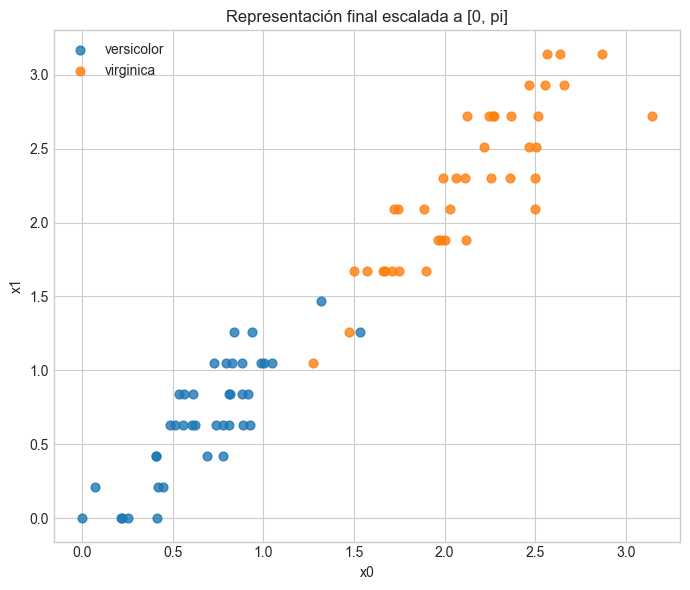

In [ ]:

fig, ax = plt.subplots(figsize=(7, 6))
for label, color in zip(sorted(np.unique(final_train_df['target'])), colors):
    mask = final_train_df['target'] == label
    ax.scatter(final_train_df.loc[mask, 'x0'], final_train_df.loc[mask, 'x1'], s=40, alpha=0.8, color=color, label=name_map[label])
ax.set_title('Representación final escalada a [0, pi]')
ax.set_xlabel('x0')
ax.set_ylabel('x1')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '10_final_angles_for_vqc.png', dpi=180, bbox_inches='tight')
plt.show()



## 9. Resumen interpretativo para el informe

Usa esta celda para generar texto base que luego puedas adaptar al informe.


In [ ]:

summary = {
    'class_pair': CLASS_PAIR,
    'class_names': list(name_map.values()),
    'best_raw_pair': ' + '.join(best_pair),
    'best_single_feature': best_single_feature,
    'best_representation': best_rep_name,
    'final_feature_names': final_feature_names,
    'train_samples': len(X_train),
    'test_samples': len(X_test)
}

summary


{'class_pair': (1, 2),
 'class_names': [np.str_('versicolor'), np.str_('virginica')],
 'best_raw_pair': 'petal length (cm) + petal width (cm)',
 'best_single_feature': 'petal width (cm)',
 'best_representation': 'lda1_plus_best_raw',
 'final_feature_names': ['lda1', 'petal width (cm)'],
 'train_samples': 80,
 'test_samples': 20}


## 10. Próximo paso para el VQC

Una vez elegida la representación final, el archivo que alimentarás al modelo es:

- `08_final_train_angles.csv`
- `09_final_test_angles.csv`

Cada archivo deja el dataset listo con:
- `x0`, `x1` en rango `[0, pi]`
- `target` binario

Eso ya está preparado para un embedding angular simple en 2 qubits.


# Comparación de Ansätze Variacionales de 2 Qubits para Clasificación Binaria

## Objetivo

Este notebook implementa la fase experimental del proyecto semestral.

El objetivo es comparar tres configuraciones de circuitos variacionales de 2 qubits:

- Ansatz Base
- Ansatz Reducido
- Ansatz Hardware-Efficient (HEA)

La comparación se realiza utilizando la representación de entrada seleccionada durante la etapa de preprocesamiento.

Además del desempeño predictivo, se analizan métricas estructurales relevantes para dispositivos NISQ, incluyendo profundidad del circuito, número de compuertas y cantidad de operaciones de dos qubits.

## Caso de estudio

Se utiliza una versión binaria del dataset Iris correspondiente a las clases:

- Versicolor
- Virginica

La representación final seleccionada durante el preprocesamiento corresponde a:

- LDA1
- Petal Width

Posteriormente ambas variables fueron escaladas al intervalo [0, π] para permitir codificación angular mediante compuertas Ry.

## Importación de librerías

Se cargan las bibliotecas necesarias para:

- manipulación de datos
- construcción de circuitos cuánticos
- simulación
- evaluación de métricas
- visualización de resultados

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score
)

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import SparsePauliOp
from qiskit import transpile

from scipy.optimize import minimize

## Carga de los conjuntos de entrenamiento y prueba

Los archivos fueron generados durante la etapa de preprocesamiento y contienen:

- x0
- x1
- target

Las variables x0 y x1 corresponden a los ángulos utilizados para la codificación cuántica.

In [ ]:
DATA_DIR = Path(
    r"C:\Users\con_l\Downloads\output_qml_feature_analysis"
)

train_df = pd.read_csv(
    DATA_DIR / "08_final_train_angles.csv"
)

test_df = pd.read_csv(
    DATA_DIR / "09_final_test_angles.csv"
)

display(train_df.head())

,x0,x1,target
0,0.532168,0.837758,0
1,2.253187,2.303835,1
2,1.720474,2.094395,1
3,1.747840,1.675516,1
4,3.141593,2.722714,1


In [ ]:
X_train = train_df[["x0", "x1"]].values
y_train = train_df["target"].values

X_test = test_df[["x0", "x1"]].values
y_test = test_df["target"].values

print(X_train.shape)
print(X_test.shape)

(80, 2)
(20, 2)


## Distribución de las muestras

Antes del entrenamiento se visualiza la representación final utilizada por el clasificador.

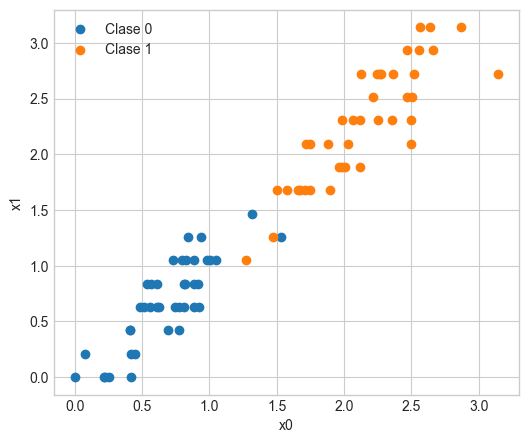

In [ ]:
plt.figure(figsize=(6,5))

for cls in np.unique(y_train):

    idx = y_train == cls

    plt.scatter(
        X_train[idx,0],
        X_train[idx,1],
        label=f"Clase {cls}"
    )

plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.show()

# Definición de circuitos variacionales

Se implementan tres variantes:

1. Base
2. Reducido
3. Hardware Efficient

Cada arquitectura representa una estrategia distinta de diseño.

## Ansatz Base

Características:

- 2 qubits
- 6 parámetros
- 2 compuertas CX
- 2 capas de entrelazamiento

In [ ]:
def circuit_base(x, theta):

    qc = QuantumCircuit(2)

    qc.ry(x[0],0)
    qc.ry(x[1],1)

    qc.ry(theta[0],0)
    qc.ry(theta[1],1)

    qc.cx(0,1)

    qc.ry(theta[2],0)
    qc.ry(theta[3],1)

    qc.cx(0,1)

    qc.ry(theta[4],0)
    qc.ry(theta[5],1)

    return qc

## Ansatz Reducido

Esta variante elimina una capa de entrelazamiento respecto al circuito base.

In [ ]:
def circuit_reduced(x, theta):

    qc = QuantumCircuit(2)

    qc.ry(x[0],0)
    qc.ry(x[1],1)

    qc.ry(theta[0],0)
    qc.ry(theta[1],1)

    qc.cx(0,1)

    qc.ry(theta[2],0)
    qc.ry(theta[3],1)

    return qc

## Hardware Efficient Ansatz

Implementación basada en rotaciones locales y una compuerta ECR.

In [ ]:
def circuit_hea(x, theta):

    qc = QuantumCircuit(2)

    qc.ry(x[0],0)
    qc.ry(x[1],1)

    qc.rx(theta[0],0)
    qc.rz(theta[1],0)

    qc.rx(theta[2],1)
    qc.rz(theta[3],1)

    qc.ecr(0,1)

    return qc

## Inspección visual de las arquitecturas

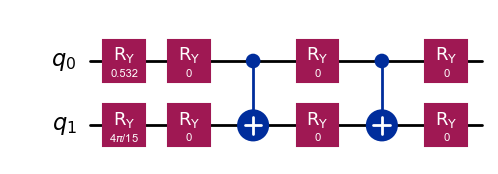

In [ ]:
theta_base = np.zeros(6)

circuit_base(
    X_train[0],
    theta_base
).draw("mpl")

## Medición del observable

La salida del clasificador se obtiene mediante el valor esperado del observable Z sobre el primer qubit.

El valor esperado se transforma posteriormente a una probabilidad binaria.

In [ ]:
OBS = SparsePauliOp.from_list(
    [("ZI",1)]
)

def predict_probability(qc):

    state = Statevector.from_instruction(qc)

    exp = np.real(
        state.expectation_value(OBS)
    )

    return (exp + 1) / 2

## Función de costo

Se utiliza Binary Cross Entropy.

In [ ]:
def bce(y_true, y_pred):

    eps = 1e-10

    y_pred = np.clip(
        y_pred,
        eps,
        1-eps
    )

    return -np.mean(
        y_true*np.log(y_pred)
        +(1-y_true)*np.log(1-y_pred)
    )

# Entrenamiento de modelos

Cada ansatz se entrena utilizando optimización clásica.

Durante el proceso se registra:

- pérdida
- accuracy
- parámetros finales

In [ ]:
def train_model(
    circuit_builder,
    n_params,
    X_train,
    y_train
):

    history = []

    def loss(theta):

        probs = []

        for x in X_train:

            qc = circuit_builder(
                x,
                theta
            )

            probs.append(
                predict_probability(qc)
            )

        probs = np.array(probs)

        current_loss = bce(
            y_train,
            probs
        )

        history.append(
            current_loss
        )

        return current_loss

    theta0 = np.random.uniform(
        -0.1,
        0.1,
        n_params
    )

    result = minimize(
        loss,
        theta0,
        method="COBYLA"
    )

    return result, history

## Entrenar los tres modelos

In [ ]:
base_result, base_history = train_model(
    circuit_base,
    6,
    X_train,
    y_train
)

reduced_result, reduced_history = train_model(
    circuit_reduced,
    4,
    X_train,
    y_train
)

hea_result, hea_history = train_model(
    circuit_hea,
    4,
    X_train,
    y_train
)

## Evolución de la pérdida

Las curvas permiten analizar la estabilidad y convergencia del entrenamiento.

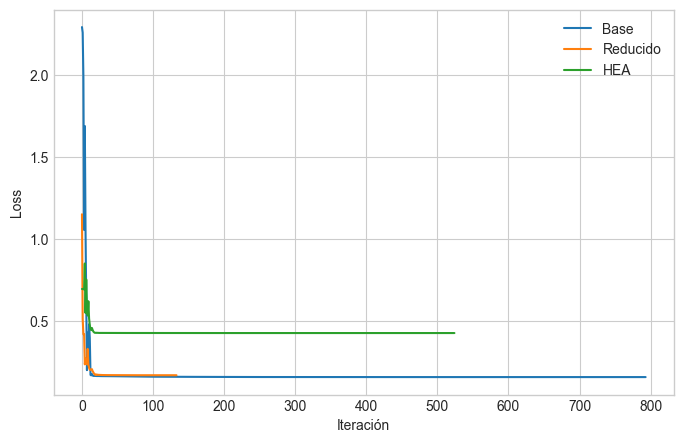

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(base_history,label="Base")
plt.plot(reduced_history,label="Reducido")
plt.plot(hea_history,label="HEA")

plt.xlabel("Iteración")
plt.ylabel("Loss")

plt.legend()
plt.show()

## Evaluación final

In [ ]:
def evaluate_model(
    circuit_builder,
    theta,
    X_test,
    y_test
):

    probs = []

    for x in X_test:

        qc = circuit_builder(
            x,
            theta
        )

        probs.append(
            predict_probability(qc)
        )

    probs = np.array(probs)

    pred = (probs > 0.5).astype(int)

    return {
        "accuracy": accuracy_score(y_test,pred),
        "f1": f1_score(y_test,pred),
        "auc": roc_auc_score(y_test,probs)
    }

In [ ]:
base_metrics = evaluate_model(
    circuit_base,
    base_result.x,
    X_test,
    y_test
)

reduced_metrics = evaluate_model(
    circuit_reduced,
    reduced_result.x,
    X_test,
    y_test
)

hea_metrics = evaluate_model(
    circuit_hea,
    hea_result.x,
    X_test,
    y_test
)

print(base_metrics)
print(reduced_metrics)
print(hea_metrics)

{'accuracy': 0.85, 'f1': 0.8421052631578947, 'auc': 0.98}
{'accuracy': 0.85, 'f1': 0.8421052631578947, 'auc': 0.95}
{'accuracy': 0.9, 'f1': 0.8888888888888888, 'auc': 1.0}


## Métricas estructurales

In [ ]:
def structural_metrics(qc):

    compiled = transpile(
        qc,
        optimization_level=3
    )

    ops = compiled.count_ops()

    two_qubit = (
        ops.get("cx", 0)
        + ops.get("ecr", 0)
    )

    return {
        "depth": compiled.depth(),
        "size": compiled.size(),
        "two_qubit_gates": two_qubit
    }

In [ ]:
base_structure = structural_metrics(
    circuit_base(
        X_train[0],
        base_result.x
    )
)

reduced_structure = structural_metrics(
    circuit_reduced(
        X_train[0],
        reduced_result.x
    )
)

hea_structure = structural_metrics(
    circuit_hea(
        X_train[0],
        hea_result.x
    )
)

print(base_structure)
print(reduced_structure)
print(hea_structure)

{'depth': 5, 'size': 8, 'two_qubit_gates': 2}
{'depth': 3, 'size': 5, 'two_qubit_gates': 1}
{'depth': 2, 'size': 3, 'two_qubit_gates': 1}


# Comparación Final

La comparación integra métricas predictivas y estructurales.

El objetivo no es únicamente maximizar accuracy, sino analizar el compromiso entre capacidad predictiva y costo estructural en hardware NISQ.

In [ ]:
results_df = pd.DataFrame([
    {
        "ansatz": "Base",
        **base_metrics,
        **base_structure
    },
    {
        "ansatz": "Reducido",
        **reduced_metrics,
        **reduced_structure
    },
    {
        "ansatz": "HEA",
        **hea_metrics,
        **hea_structure
    }
])

results_df = results_df.sort_values(
    by="accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,ansatz,accuracy,f1,auc,depth,size,two_qubit_gates
0,HEA,0.90,0.888889,1.00,2,3,1
1,Base,0.85,0.842105,0.98,5,8,2
2,Reducido,0.85,0.842105,0.95,3,5,1


In [ ]:
results_df.to_csv(
    "ansatz_comparison_results.csv",
    index=False
)

results_df

,ansatz,accuracy,f1,auc,depth,size,two_qubit_gates
0,HEA,0.90,0.888889,1.00,2,3,1
1,Base,0.85,0.842105,0.98,5,8,2
2,Reducido,0.85,0.842105,0.95,3,5,1


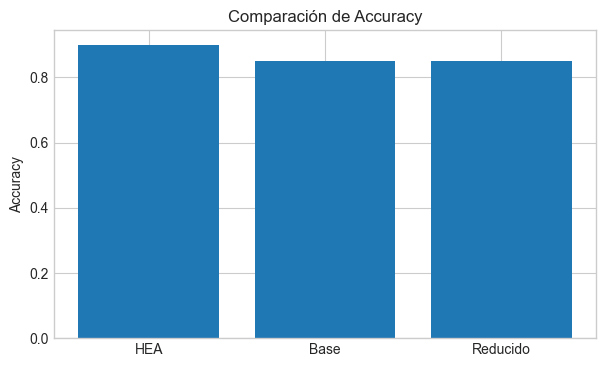

In [ ]:
plt.figure(figsize=(7,4))

plt.bar(
    results_df["ansatz"],
    results_df["accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Comparación de Accuracy")

plt.show()

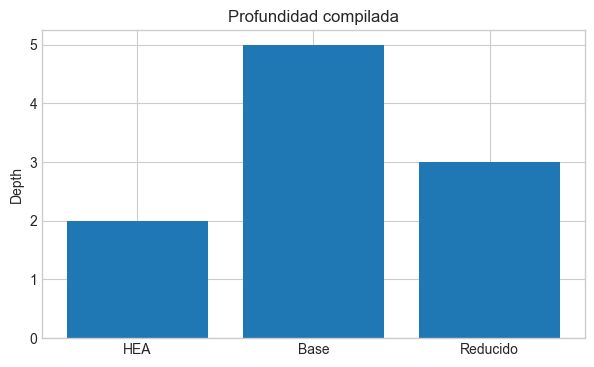

In [ ]:
plt.figure(figsize=(7,4))

plt.bar(
    results_df["ansatz"],
    results_df["depth"]
)

plt.ylabel("Depth")
plt.title("Profundidad compilada")

plt.show()

In [ ]:
results_df

,ansatz,accuracy,f1,auc,depth,size,two_qubit_gates
0,HEA,0.90,0.888889,1.00,2,3,1
1,Base,0.85,0.842105,0.98,5,8,2
2,Reducido,0.85,0.842105,0.95,3,5,1
